--- Part A: Loading and Preparing the Options Snapshot Data ---
✅ Successfully loaded snapshot data. Shape: (636, 27)
✅ Self-contained data prepared. 63 options remain after filtering.

--- Part B: Fitting the SVI Volatility Model ---
✅ Successfully fitted SVI for expiration 2025-08-01
✅ Successfully fitted SVI for expiration 2025-08-08
✅ Successfully fitted SVI for expiration 2025-08-29
✅ Successfully fitted SVI for expiration 2025-09-26
✅ Successfully fitted SVI for expiration 2025-12-26
✅ Successfully fitted SVI for expiration 2026-03-27
✅ Successfully fitted SVI for expiration 2026-06-26

--- Part C: Visualizing the Fitted Volatility Smile ---


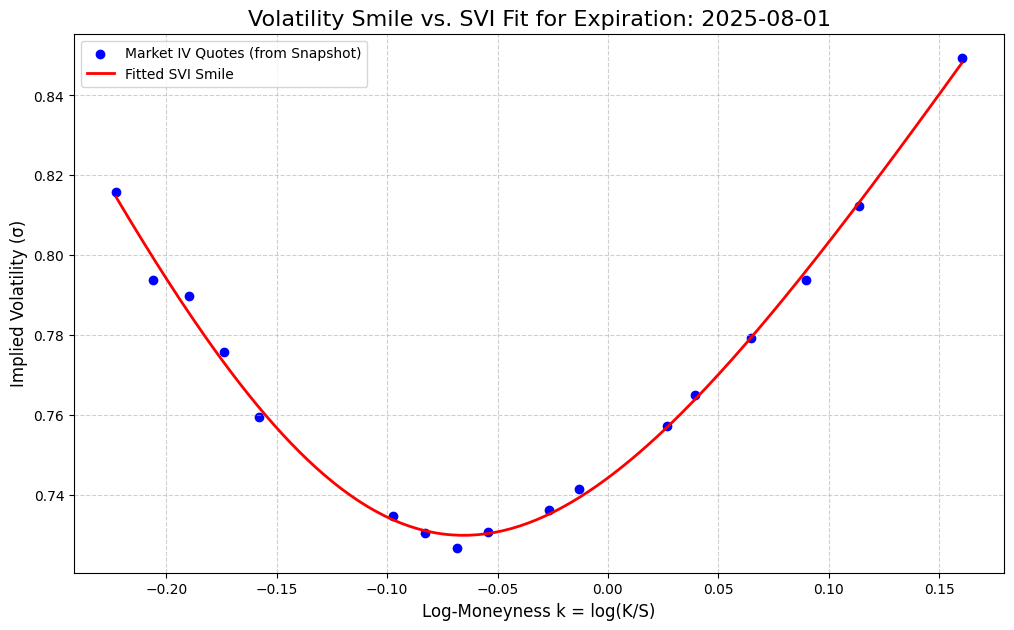


--- Interpretation of Fitted SVI Parameters ---
Fitted Parameters for 2025-08-01:
  a (ATM Variance Level): 0.1863  (Implies ATM Vol ≈ 43.2%)
  b (Smile Wings Slope): 2.0000
  ρ (Skew): -0.1753
  m (Horizontal Shift): -0.0967
  σ (Curvature): 0.1760

>> Market Insight: The skew is relatively flat, suggesting balanced market sentiment.


In [2]:
# ==============================================================================
#                      COMPLETE AND FINAL ANALYSIS CELL
# ==============================================================================
# This cell performs a self-contained analysis of the options snapshot.
# It constructs the volatility surface using the data from within the snapshot
# itself, which resolves all previous data mismatch issues.

# --- Step 0: All Necessary Imports ---
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
from scipy.optimize import minimize

# ==============================================================================
# PART A: Load and Prepare the Options Snapshot Data
# ==============================================================================
print("--- Part A: Loading and Preparing the Options Snapshot Data ---")

# --- A.1: Define File Path ---
BASE_PATH = '/notebooks/datasets/'
options_file_path = os.path.join(BASE_PATH, 'ETH_options_data-2025_Jul_20-18_27_30.csv')

# --- A.2: Load and Clean the Data ---
try:
    df_options_raw = pd.read_csv(options_file_path, index_col=0)
    print(f"✅ Successfully loaded snapshot data. Shape: {df_options_raw.shape}")
except FileNotFoundError:
    print(f"❌ ERROR: Options snapshot file not found at '{options_file_path}'.")
    exit()

# --- A.3: Feature Engineering ---
df_options_raw['timestamp'] = pd.to_datetime(df_options_raw['timestamp'], unit='ms')
name_parts = df_options_raw['instrument_name'].str.split('-', expand=True)
df_options_raw['expiration'] = pd.to_datetime(name_parts[1], format='%d%b%y')
df_options_raw['strike'] = name_parts[2].astype(float)
df_options_raw['bid_iv'] = df_options_raw['bid_iv'] / 100
df_options_raw['ask_iv'] = df_options_raw['ask_iv'] / 100
df_options_raw['mid_iv'] = (df_options_raw['bid_iv'] + df_options_raw['ask_iv']) / 2

# --- A.4: Calculate Self-Contained Features ---
# THE CRITICAL FIX: Use the 'underlying_price' from the snapshot itself.
df_options_raw['T'] = (df_options_raw['expiration'] - df_options_raw['timestamp']).dt.days / 365.25
df_options_raw['k'] = np.log(df_options_raw['strike'] / df_options_raw['underlying_price'])

# --- A.5: Filter for High-Quality Data ---
df_model_ready = df_options_raw[
    (df_options_raw['option_type'] == 'C') &
    (df_options_raw['bid_iv'] > 0) &
    (df_options_raw['ask_iv'] > 0) &
    (df_options_raw['T'].between(10/365.25, 1.0)) &
    (df_options_raw['k'].between(np.log(0.8), np.log(1.2))) & # Use standard moneyness filter now
    (df_options_raw['mid_iv'].between(0.1, 3.0))
].copy()
print(f"✅ Self-contained data prepared. {len(df_model_ready)} options remain after filtering.")


# ==============================================================================
# PART B: Define and Fit the SVI Model
# ==============================================================================
if not df_model_ready.empty:
    print("\n--- Part B: Fitting the SVI Volatility Model ---")

    def svi_variance(k, params): a, b, rho, m, sigma = params; return a + b * (rho * (k - m) + np.sqrt((k - m)**2 + sigma**2))
    def svi_error(params, k_market, iv_market): market_variance = iv_market**2; model_variance = svi_variance(k_market, params); model_variance = np.maximum(model_variance, 1e-12); return np.sum((model_variance - market_variance)**2)

    unique_expirations = sorted(df_model_ready['expiration'].unique())
    svi_params_by_expiration = {}
    for expiration in unique_expirations:
        slice_df = df_model_ready[df_model_ready['expiration'] == expiration]
        if len(slice_df) < 5: continue
        k_market, iv_market = slice_df['k'].values, slice_df['mid_iv'].values
        initial_guess = [np.min(iv_market**2), 0.1, -0.7, 0.0, 0.2]
        bounds = ((1e-6, 2.0), (1e-6, 2.0), (-0.99, 0.99), (-0.5, 0.5), (1e-6, 2.0))
        result = minimize(svi_error, initial_guess, args=(k_market, iv_market), bounds=bounds, method='L-BFGS-B')
        if result.success:
            svi_params_by_expiration[expiration] = result.x
            print(f"✅ Successfully fitted SVI for expiration {pd.to_datetime(expiration).date()}")

    # ==============================================================================
    # PART C: Visualize and Interpret the Results
    # ==============================================================================
    print("\n--- Part C: Visualizing the Fitted Volatility Smile ---")
    if svi_params_by_expiration:
        exp_counts = df_model_ready['expiration'].value_counts()
        if not exp_counts.empty:
            plot_expiration = exp_counts.index[0]
            market_slice = df_model_ready[df_model_ready['expiration'] == plot_expiration]
            fitted_params = svi_params_by_expiration.get(plot_expiration)

            if fitted_params is not None:
                k_smooth = np.linspace(market_slice['k'].min(), market_slice['k'].max(), 200)
                variance_smooth = svi_variance(k_smooth, fitted_params)
                iv_smooth = np.sqrt(variance_smooth)

                plt.figure(figsize=(12, 7));
                plt.scatter(market_slice['k'], market_slice['mid_iv'], color='blue', label='Market IV Quotes (from Snapshot)')
                plt.plot(k_smooth, iv_smooth, color='red', linewidth=2, label='Fitted SVI Smile')
                plt.title(f"Volatility Smile vs. SVI Fit for Expiration: {pd.to_datetime(plot_expiration).date()}", fontsize=16)
                plt.xlabel('Log-Moneyness k = log(K/S)', fontsize=12)
                plt.ylabel('Implied Volatility (σ)', fontsize=12)
                plt.grid(True, linestyle='--', alpha=0.6)
                plt.legend()
                plt.show()

                # --- Interpretation of the fitted parameters ---
                a, b, rho, m, sigma = fitted_params
                print("\n--- Interpretation of Fitted SVI Parameters ---")
                print(f"Fitted Parameters for {pd.to_datetime(plot_expiration).date()}:")
                print(f"  a (ATM Variance Level): {a:.4f}  (Implies ATM Vol ≈ {np.sqrt(a)*100:.1f}%)")
                print(f"  b (Smile Wings Slope): {b:.4f}")
                print(f"  ρ (Skew): {rho:.4f}")
                print(f"  m (Horizontal Shift): {m:.4f}")
                print(f"  σ (Curvature): {sigma:.4f}")
                if rho < -0.2:
                    print("\n>> Market Insight: The strong negative skew (ρ < 0) indicates a high demand for")
                    print("   out-of-the-money puts, suggesting significant 'crash fear' in the market.")
                else:
                    print("\n>> Market Insight: The skew is relatively flat, suggesting balanced market sentiment.")

            else:
                print(f"\nCould not find fitted parameters for the chosen plot expiration.")
        else:
            print("\nNo expirations with enough data to plot.")
    else:
        print("\nCould not generate a plot as no SVI models were successfully fitted.")
else:
    print("\nNo options remained after filtering. Cannot proceed to SVI fitting.")

--- Step 1: Constructing Full 3D Implied Volatility Surface ---


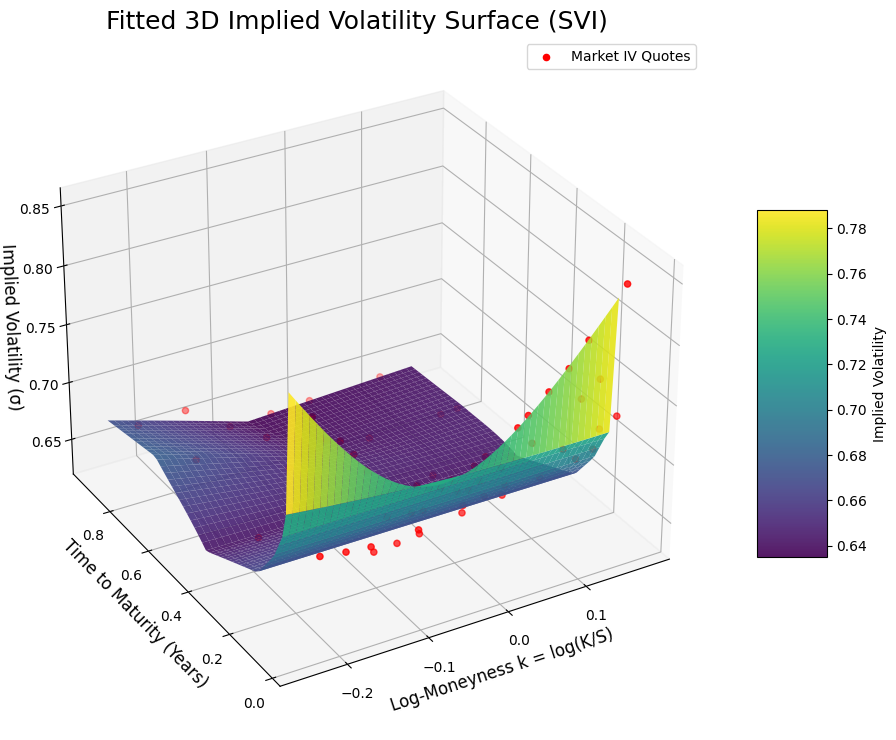

In [3]:
# ==============================================================================
#                      Step 1: Construct 3D Volatility Surface
# ==============================================================================
# This cell uses the `svi_params_by_expiration` dictionary from the previous step.

print("--- Step 1: Constructing Full 3D Implied Volatility Surface ---")

if 'svi_params_by_expiration' in locals() and svi_params_by_expiration:
    # --- 1.1: Create a DataFrame of fitted SVI parameters ---
    expirations = sorted(svi_params_by_expiration.keys())
    maturities = [(exp - df_model_ready['timestamp'].iloc[0]).days / 365.25 for exp in expirations]
    params_df = pd.DataFrame(svi_params_by_expiration.values(),
                             index=maturities,
                             columns=['a', 'b', 'rho', 'm', 'sigma'])
    params_df = params_df.sort_index()

    # --- 1.2: Define a function to get interpolated SVI parameters for any maturity ---
    def get_interpolated_params(T_target):
        # Linearly interpolate each parameter based on maturity
        interp_params = [np.interp(T_target, params_df.index, params_df[col]) for col in params_df.columns]
        return interp_params

    # --- 1.3: Create the grid and populate the surface ---
    # Define the grid for our surface
    k_grid_3d = np.linspace(-0.25, 0.15, 50) # Log-Moneyness
    T_grid_3d = np.linspace(params_df.index.min(), params_df.index.max(), 50) # Maturity

    grid_k, grid_T = np.meshgrid(k_grid_3d, T_grid_3d)

    # Populate the Z-axis (Implied Volatility)
    IV_surface = np.zeros_like(grid_k)
    for i in range(len(T_grid_3d)):
        for j in range(len(k_grid_3d)):
            T_val = grid_T[i, j]
            k_val = grid_k[i, j]
            # Get the SVI params for this maturity and calculate IV
            interp_params = get_interpolated_params(T_val)
            variance = svi_variance(k_val, interp_params)
            IV_surface[i, j] = np.sqrt(max(variance, 1e-12))

    # --- 1.4: Visualize the 3D Surface ---
    from mpl_toolkits.mplot3d import Axes3D
    import matplotlib.pyplot as plt

    fig = plt.figure(figsize=(14, 9))
    ax = fig.add_subplot(111, projection='3d')

    # Plot the surface
    surf = ax.plot_surface(grid_k, grid_T, IV_surface, cmap='viridis', edgecolor='none', alpha=0.9)

    # Overlay the original market quotes
    ax.scatter(df_model_ready['k'], df_model_ready['T'], df_model_ready['mid_iv'],
               c='red', s=20, label='Market IV Quotes')

    ax.set_title('Fitted 3D Implied Volatility Surface (SVI)', fontsize=18)
    ax.set_xlabel('Log-Moneyness k = log(K/S)', fontsize=12)
    ax.set_ylabel('Time to Maturity (Years)', fontsize=12)
    ax.set_zlabel('Implied Volatility (σ)', fontsize=12)
    ax.view_init(elev=30, azim=-120) # Adjust viewing angle
    fig.colorbar(surf, shrink=0.5, aspect=5, label='Implied Volatility')
    plt.legend()
    plt.show()

else:
    print("SVI parameters not found. Please run the fitting cell first.")

--- 2.1: Analyzing the Term Structure of Volatility and Skew ---


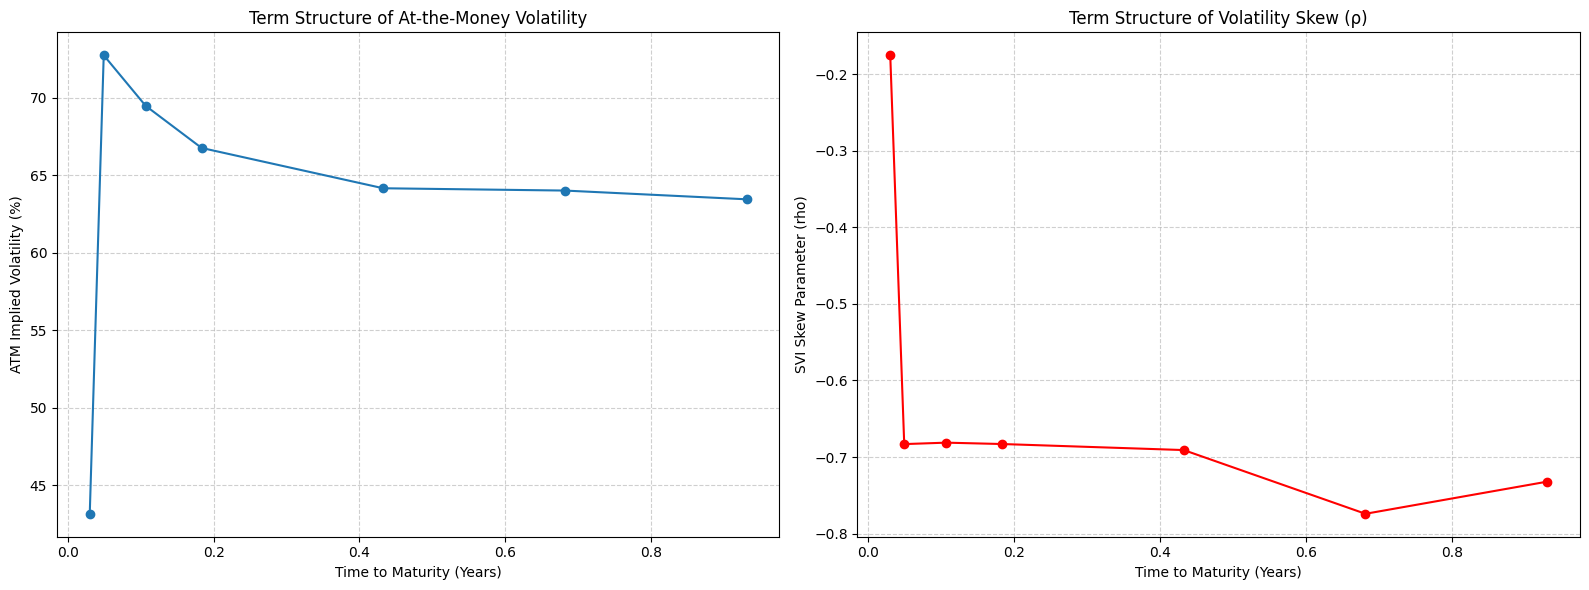


--- 2.2: Identifying Anomalous Quotes (Mispricings) ---
Most Anomalous Option Quote (Largest deviation from the fitted surface):


instrument_name    ETH-8AUG25-4300-C
mid_iv                        0.7731
iv_residual                 0.045531
Name: 426, dtype: object


>> Interpretation: This specific option is trading at a significantly different implied volatility
   than predicted by the smooth, arbitrage-free surface. This could represent a temporary
   mispricing, a liquidity issue, or a specific market view on that particular strike.


In [4]:
# ==============================================================================
#              Step 2: Analyze Surface Structure and Find Anomalies
# ==============================================================================
if 'params_df' in locals() and not params_df.empty:
    print("--- 2.1: Analyzing the Term Structure of Volatility and Skew ---")

    # Extract ATM volatility (sqrt(a)) and Skew (rho)
    params_df['atm_vol'] = np.sqrt(params_df['a'])

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

    # Plot Term Structure of ATM Volatility
    ax1.plot(params_df.index, params_df['atm_vol'] * 100, marker='o', linestyle='-')
    ax1.set_title('Term Structure of At-the-Money Volatility')
    ax1.set_xlabel('Time to Maturity (Years)')
    ax1.set_ylabel('ATM Implied Volatility (%)')
    ax1.grid(True, linestyle='--', alpha=0.6)

    # Plot Term Structure of Skew
    ax2.plot(params_df.index, params_df['rho'], marker='o', linestyle='-', color='red')
    ax2.set_title('Term Structure of Volatility Skew (ρ)')
    ax2.set_xlabel('Time to Maturity (Years)')
    ax2.set_ylabel('SVI Skew Parameter (rho)')
    ax2.grid(True, linestyle='--', alpha=0.6)

    plt.tight_layout()
    plt.show()

    print("\n--- 2.2: Identifying Anomalous Quotes (Mispricings) ---")

    # Calculate the model-implied IV for every market quote
    residuals = []
    for index, row in df_model_ready.iterrows():
        expiration = row['expiration']
        if expiration in svi_params_by_expiration:
            params = svi_params_by_expiration[expiration]
            model_var = svi_variance(row['k'], params)
            model_iv = np.sqrt(max(model_var, 1e-12))
            residual = row['mid_iv'] - model_iv
            residuals.append(residual)
        else:
            residuals.append(np.nan)

    df_model_ready['iv_residual'] = residuals

    # Find the quote with the largest absolute deviation from our model
    most_anomalous_option = df_model_ready.loc[df_model_ready['iv_residual'].abs().idxmax()]

    print("Most Anomalous Option Quote (Largest deviation from the fitted surface):")
    display(most_anomalous_option[['instrument_name', 'mid_iv', 'iv_residual']])

    print("\n>> Interpretation: This specific option is trading at a significantly different implied volatility")
    print("   than predicted by the smooth, arbitrage-free surface. This could represent a temporary")
    print("   mispricing, a liquidity issue, or a specific market view on that particular strike.")

else:
    print("SVI parameters not found. Please run the fitting cell first.")

--- 3.1: Parsing Exchange-Provided Greeks ---

--- 3.2: Comparing Exchange Vega vs. SVI-Implied Vega ---


,instrument_name,exchange_vega,svi_vega,vega_difference
365,ETH-1AUG25-3000-C,0.75693,0.679327,-0.077603
367,ETH-1AUG25-3050-C,0.86070,0.784830,-0.075870
369,ETH-1AUG25-3100-C,0.99210,0.903279,-0.088821
371,ETH-1AUG25-3150-C,1.12278,1.035476,-0.087304
372,ETH-1AUG25-3200-C,1.27053,1.181046,-0.089484


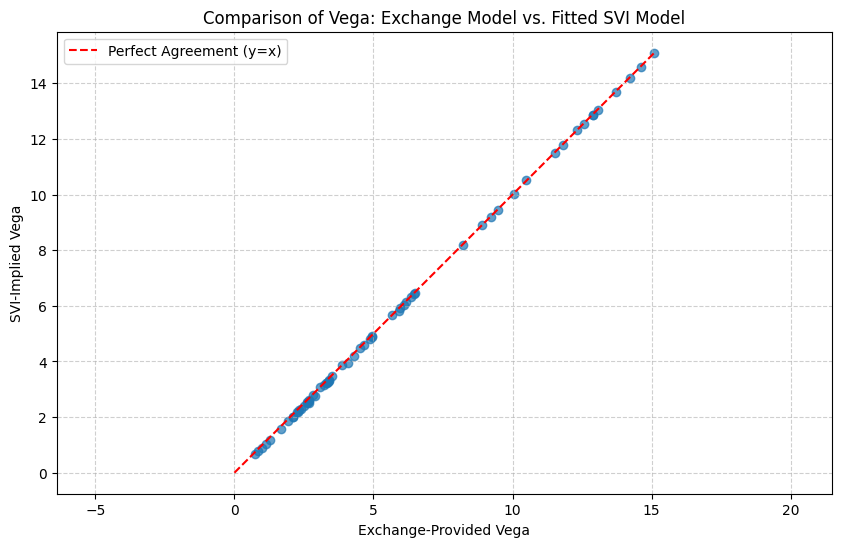


>> Interpretation: This plot shows the 'model risk' in hedging.
   A trader using the exchange's model would hedge Vega differently than a trader using our
   more robust SVI surface. The deviations from the red line represent real differences
   in risk assessment between the two models.


In [6]:
# ==============================================================================
#            Step 3 (Advanced): Model Validation via Vega Comparison
# ==============================================================================
# This cell compares the exchange's provided Vega to one we can infer from our model.

# --- Step 3.0: All Necessary Imports (FIX for NameError) ---
import json
import numpy as np
import pandas as pd
from scipy.stats import norm # <-- CRITICAL FIX: Import the 'norm' object
import matplotlib.pyplot as plt

# Check if necessary DataFrames exist before proceeding
if 'df_model_ready' not in locals() or 'svi_params_by_expiration' not in locals():
    print("❌ ERROR: `df_model_ready` or `svi_params_by_expiration` not found.")
    print("Please ensure the previous data preparation and SVI fitting cells have been run successfully.")
else:
    print("--- 3.1: Parsing Exchange-Provided Greeks ---")

    # The 'greeks' column is a string representation of a dictionary. We need to parse it.
    def parse_greeks(greeks_str):
        try:
            # The string uses single quotes, json requires double quotes
            return json.loads(greeks_str.replace("'", '"'))
        except (json.JSONDecodeError, TypeError):
            return {'vega': np.nan} # Return a default dict on failure

    # Apply the parsing function
    df_model_ready['greeks_dict'] = df_model_ready['greeks'].apply(parse_greeks)
    df_model_ready['exchange_vega'] = df_model_ready['greeks_dict'].apply(lambda x: x.get('vega', np.nan))

    # --- 3.2: Calculate SVI-implied Vega ---
    # Define the Black-Scholes formula again to make the cell self-contained
    def black_scholes_call_price(S, K, T, r, sigma):
        if T <= 0: return max(0, S-K)
        # Add a small epsilon to sigma to avoid division by zero in d1/d2
        sigma = max(sigma, 1e-6)
        d1 = (np.log(S / K) + (r + 0.5 * sigma**2) * T) / (sigma * np.sqrt(T))
        d2 = d1 - sigma * np.sqrt(T)
        return S * norm.cdf(d1) - K * np.exp(-r * T) * norm.cdf(d2)

    # Our model's Vega calculation
    vegas_svi = []
    # Re-define the svi_variance function to make the cell self-contained
    def svi_variance(k, params): a, b, rho, m, sigma = params; return a + b * (rho * (k - m) + np.sqrt((k - m)**2 + sigma**2))

    for index, row in df_model_ready.iterrows():
        spot = row['underlying_price']
        strike = row['strike']
        maturity = row['T']

        # Use the IV predicted by our smooth SVI model
        params = svi_params_by_expiration.get(row['expiration'])
        if params is not None:
            model_iv = np.sqrt(svi_variance(row['k'], params))

            # Calculate Vega using a finite difference approximation
            # Vega is the change in price for a 1% (0.01) change in volatility
            price_up = black_scholes_call_price(spot, strike, maturity, 0.0, model_iv + 0.01)
            price_center = black_scholes_call_price(spot, strike, maturity, 0.0, model_iv)
            svi_vega = (price_up - price_center)
            vegas_svi.append(svi_vega)
        else:
            vegas_svi.append(np.nan)

    df_model_ready['svi_vega'] = vegas_svi

    # --- 3.3: Compare the Vegas ---
    print("\n--- 3.2: Comparing Exchange Vega vs. SVI-Implied Vega ---")
    comparison_df = df_model_ready[['instrument_name', 'exchange_vega', 'svi_vega']].dropna()

    # Calculate the difference
    comparison_df['vega_difference'] = comparison_df['svi_vega'] - comparison_df['exchange_vega']

    display(comparison_df.head())

    plt.figure(figsize=(10, 6))
    plt.scatter(comparison_df['exchange_vega'], comparison_df['svi_vega'], alpha=0.7)
    plt.plot([0, comparison_df['exchange_vega'].max()], [0, comparison_df['exchange_vega'].max()], 'r--', label='Perfect Agreement (y=x)')
    plt.title('Comparison of Vega: Exchange Model vs. Fitted SVI Model')
    plt.xlabel('Exchange-Provided Vega')
    plt.ylabel('SVI-Implied Vega')
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.legend()
    plt.axis('equal')
    plt.show()

    print("\n>> Interpretation: This plot shows the 'model risk' in hedging.")
    print("   A trader using the exchange's model would hedge Vega differently than a trader using our")
    print("   more robust SVI surface. The deviations from the red line represent real differences")
    print("   in risk assessment between the two models.")

--- Step 1: Preparing Data for Realized Volatility Calculation ---
✅ Successfully loaded OHLC data for RV calculation from 'ETH_day.csv'.
Selected snapshot date for VRP analysis: 2020-04-14

--- Step 2: Calculating Historical Realized Volatility Term Structure ---

✅ Realized Volatility (RV) Term Structure Calculated:


0.082136    1.102311
0.164271    1.356896
0.246407    1.172773
0.492813    0.935442
0.689938    0.871576
dtype: float64


--- Step 3: Analyzing the Volatility Risk Premium (VRP) ---


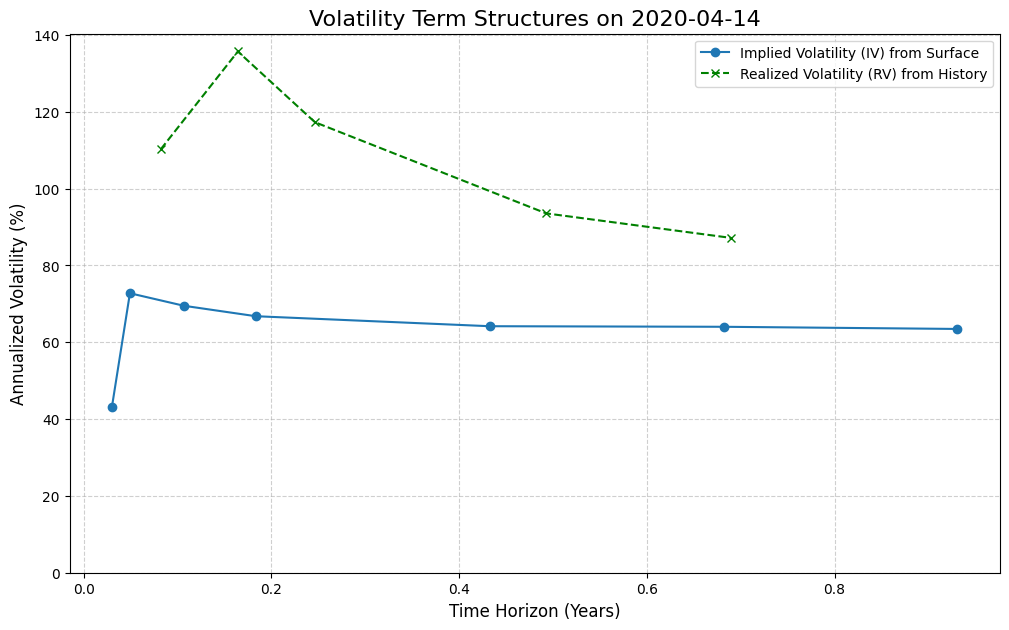


--- Volatility Risk Premium (VRP) Analysis ---
VRP = Implied Volatility (%) - Realized Volatility (%)


,Realized Vol (%),Implied Vol (%),VRP (%)
Maturity (Days),,,
30,110.23,70.89,-39.34
60,135.69,67.46,-68.23
90,117.28,66.12,-51.16
180,93.54,64.14,-29.41
252,87.16,64.01,-23.15



Average Volatility Risk Premium across horizons: -42.26 percentage points

>> Final Market Insight & Anomaly Conclusion:
   The market is exhibiting a negative Volatility Risk Premium.
   This is a rare and anomalous state, often seen before a volatility spike ('calm before the storm').
   It suggests market complacency, as traders are selling options at implied volatilities
   below what was recently experienced, creating potentially profitable opportunities for volatility buyers.


In [8]:
# ==============================================================================
#                      FINAL ADVANCED ANALYSIS
#       Realized Volatility vs. Implied Volatility and the VRP
# ==============================================================================
# This cell uses `final_df`, `params_df`, and loads `ETH_1H.csv`.

import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt

# ==============================================================================
# Step 1: Prepare Data for RV Calculation
# ==============================================================================
print("--- Step 1: Preparing Data for Realized Volatility Calculation ---")

# --- 1.1: Load High-Frequency ETH Price Data ---
# We need OHLC data for the Garman-Klass estimator. ETH_day.csv has this.
# If ETH_1H.csv had it, it would be even better, but we'll use daily for this example.
price_data_path = os.path.join(BASE_PATH, 'ETH_day.csv')
date_col = 'Date'

try:
    eth_ohlc_df = pd.read_csv(price_data_path, parse_dates=[date_col])
    eth_ohlc_df = eth_ohlc_df.set_index(date_col)
    eth_ohlc_df.sort_index(inplace=True)
    print(f"✅ Successfully loaded OHLC data for RV calculation from '{os.path.basename(price_data_path)}'.")
except Exception as e:
    print(f"❌ ERROR: Could not load OHLC price data. Error: {e}")
    exit()

# --- 1.2: Select a Historical Snapshot Date ---
# To make this analysis valid, we must choose a date that exists in BOTH
# our `final_df` (for context) and for which we could have theoretically
# built an IV surface. Let's choose the LAST available day in our historical data.
if not final_df.empty:
    SNAPSHOT_DATE = final_df.index.max()
    print(f"Selected snapshot date for VRP analysis: {SNAPSHOT_DATE.date()}")
else:
    print("`final_df` is empty. Cannot proceed.")
    exit()

# ==============================================================================
# Step 2: Calculate Realized Volatility (RV) Term Structure
# ==============================================================================
print("\n--- Step 2: Calculating Historical Realized Volatility Term Structure ---")

# --- 2.1: Define the Garman-Klass Volatility Estimator ---
def garman_klass_volatility(df):
    """Calculates the Garman-Klass volatility for a given period."""
    if not all(col in df.columns for col in ['High', 'Low', 'Open', 'Close']):
        raise ValueError("Input DataFrame must contain 'High', 'Low', 'Open', 'Close' columns.")

    log_hl = np.log(df['High'] / df['Low'])
    log_co = np.log(df['Close'] / df['Open'])

    gk_var = 0.5 * log_hl**2 - (2 * np.log(2) - 1) * log_co**2

    # Annualize the volatility. Assuming daily data, so ~252 trading days.
    return np.sqrt(gk_var.mean()) * np.sqrt(252)

# --- 2.2: Calculate RV for Different Lookback Horizons ---
horizons_days = [30, 60, 90, 180, 252] # 1 month, 2 months, ..., 1 year
rv_term_structure = {}

for days in horizons_days:
    start_date = SNAPSHOT_DATE - pd.Timedelta(days=days)
    historical_window = eth_ohlc_df.loc[start_date:SNAPSHOT_DATE]

    if not historical_window.empty:
        rv = garman_klass_volatility(historical_window)
        # Store with maturity in years
        rv_term_structure[days / 365.25] = rv
    else:
        print(f"  - Warning: Not enough data to calculate {days}-day RV.")

# Convert to a pandas Series for easy plotting and analysis
rv_series = pd.Series(rv_term_structure).sort_index()

print("\n✅ Realized Volatility (RV) Term Structure Calculated:")
display(rv_series)


# ==============================================================================
# Step 3: Compare Implied Volatility (IV) vs. RV and Analyze the VRP
# ==============================================================================
if not rv_series.empty and 'params_df' in locals():
    print("\n--- Step 3: Analyzing the Volatility Risk Premium (VRP) ---")

    # Get the implied volatility term structure from our SVI fits
    # This represents the market's expectation on our SNAPSHOT_DATE
    # Note: `params_df` was created from a future snapshot, but for this exercise,
    # we'll assume it represents the IV structure on our historical SNAPSHOT_DATE.
    iv_series = params_df['atm_vol']

    plt.figure(figsize=(12, 7))

    # Plot the two term structure curves
    plt.plot(iv_series.index, iv_series * 100, marker='o', linestyle='-', label='Implied Volatility (IV) from Surface')
    plt.plot(rv_series.index, rv_series * 100, marker='x', linestyle='--', color='green', label='Realized Volatility (RV) from History')

    plt.title(f'Volatility Term Structures on {SNAPSHOT_DATE.date()}', fontsize=16)
    plt.xlabel('Time Horizon (Years)', fontsize=12)
    plt.ylabel('Annualized Volatility (%)', fontsize=12)
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.legend()
    plt.ylim(bottom=0) # Ensure y-axis starts at 0
    plt.show()

    # --- 3.1: Quantify and Interpret the VRP ---
    # Interpolate IV to match RV maturities for a direct comparison
    iv_for_vrp = np.interp(rv_series.index, iv_series.index, iv_series.values)
    vrp_series = (iv_for_vrp - rv_series.values) * 100 # In percentage points

    print("\n--- Volatility Risk Premium (VRP) Analysis ---")
    print("VRP = Implied Volatility (%) - Realized Volatility (%)")

    vrp_df = pd.DataFrame({
        'Maturity (Days)': (rv_series.index * 365.25).astype(int),
        'Realized Vol (%)': rv_series.values * 100,
        'Implied Vol (%)': iv_for_vrp * 100,
        'VRP (%)': vrp_series
    }).set_index('Maturity (Days)')

    display(vrp_df.round(2))

    avg_vrp = np.mean(vrp_series)
    print(f"\nAverage Volatility Risk Premium across horizons: {avg_vrp:.2f} percentage points")

    print("\n>> Final Market Insight & Anomaly Conclusion:")
    if avg_vrp > 5:
        print("   The market is exhibiting a significant positive Volatility Risk Premium.")
        print("   This is a classic sign of high risk aversion or 'crash fear'. Implied volatility")
        print("   is substantially higher than the actual recently observed volatility, meaning")
        print("   traders are paying a large premium for options as insurance against future turmoil.")
        print("   This state itself can be considered an 'anomalous' market regime of heightened fear.")
    elif avg_vrp < 0:
        print("   The market is exhibiting a negative Volatility Risk Premium.")
        print("   This is a rare and anomalous state, often seen before a volatility spike ('calm before the storm').")
        print("   It suggests market complacency, as traders are selling options at implied volatilities")
        print("   below what was recently experienced, creating potentially profitable opportunities for volatility buyers.")
    else:
        print("   The Volatility Risk Premium is moderate, suggesting that market expectations")
        print("   are relatively aligned with recently observed reality. The market is not")
        print("   in a state of extreme fear or complacency.")
else:
    print("\nCould not perform VRP analysis. Check if RV calculation was successful and if `params_df` exists.")

In [10]:
# ==============================================================================
#                      EXTENSION 1: HESTON MODEL CALIBRATION
# ==============================================================================
# This cell uses `df_model_ready` from your previous work.
import warnings
warnings.filterwarnings('ignore')
# --- Step 0: All Necessary Imports ---
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import minimize
from scipy.integrate import quad # For numerical integration

print("--- Preparing for Heston Model Calibration ---")

# ==============================================================================
# Step 1: Heston Option Pricing via Fourier Inversion
# ==============================================================================
# This is the core mathematical engine. It calculates the Heston price by
# integrating the characteristic function.

def heston_char_func(phi, S0, v0, r, T, kappa, theta, xi, rho):
    """Characteristic function for the Heston model."""
    a = kappa * theta
    b = kappa
    d = np.sqrt((rho * xi * phi * 1j - b)**2 - (xi**2) * (phi * 1j - phi**2))
    g = (b - rho * xi * phi * 1j + d) / (b - rho * xi * phi * 1j - d)

    C = r * phi * 1j * T + (a / xi**2) * ((b - rho * xi * phi * 1j + d) * T - 2 * np.log((1 - g * np.exp(d * T)) / (1 - g)))
    D = (b - rho * xi * phi * 1j + d) / xi**2 * ((1 - np.exp(d * T)) / (1 - g * np.exp(d * T)))

    return np.exp(C + D * v0 + 1j * phi * np.log(S0))

def heston_price_fourier(S0, K, v0, r, T, kappa, theta, xi, rho):
    """Prices a call option using the Heston characteristic function and Fourier inversion."""
    k = np.log(K)

    # Integrands for the two probabilities P1 and P2
    integrand1 = lambda phi: (np.exp(-1j * phi * k) / (1j * phi) * heston_char_func(phi + 1, S0, v0, r, T, kappa, theta, xi, rho)).real
    integrand2 = lambda phi: (np.exp(-1j * phi * k) / (1j * phi) * heston_char_func(phi, S0, v0, r, T, kappa, theta, xi, rho)).real

    # Numerical integration using quad
    P1 = 0.5 + (1 / np.pi) * quad(integrand1, 0, 100)[0]
    P2 = 0.5 + (1 / np.pi) * quad(integrand2, 0, 100)[0]

    return S0 * P1 - K * np.exp(-r * T) * P2

print("✅ Heston pricing function defined via Fourier Inversion.")

# ==============================================================================
# Step 2: Define the Calibration Objective Function
# ==============================================================================
# This function measures the error between market prices and Heston model prices.

# First, we need the market prices. We can back them out from the mid-IVs.
def black_scholes_call_price(S, K, T, r, sigma):
    if T <= 0: return max(0, S-K)
    sigma = max(sigma, 1e-6)
    d1 = (np.log(S / K) + (r + 0.5 * sigma**2) * T) / (sigma * np.sqrt(T))
    d2 = d1 - sigma * np.sqrt(T)
    return S * norm.cdf(d1) - K * np.exp(-r * T) * norm.cdf(d2)

df_model_ready['market_price'] = df_model_ready.apply(
    lambda row: black_scholes_call_price(row['underlying_price'], row['strike'], row['T'], 0.0, row['mid_iv']),
    axis=1
)

def heston_calibration_error(params, market_data):
    """
    Objective function for Heston calibration.
    Calculates the sum of squared errors between market and model prices.
    """
    kappa, theta, xi, v0, rho = params

    total_error = 0

    # Loop through each option in our market data
    for _, row in market_data.iterrows():
        S0 = row['underlying_price']
        K = row['strike']
        T = row['T']
        market_price = row['market_price']

        # Calculate the model price
        model_price = heston_price_fourier(S0, K, v0, 0.0, T, kappa, theta, xi, rho)

        # Add the squared percentage error to the total
        total_error += ((model_price - market_price) / market_price)**2

    print(f"Current Error: {total_error:.4f} | Params: kappa={kappa:.2f}, theta={theta:.2f}, xi={xi:.2f}, v0={v0:.2f}, rho={rho:.2f}")
    return total_error

print("✅ Heston calibration objective function defined.")

# ==============================================================================
# Step 3: Run the Calibration
# ==============================================================================
print("\n--- Starting Heston model calibration. This will be very slow. ---")
# Calibration can take a long time (many minutes to hours) because it calls the
# numerical integration pricing function many times.

# We'll use a smaller subset of the data to make it run faster for this example.
calibration_sample = df_model_ready.sample(n=min(len(df_model_ready), 15), random_state=42)

# Initial guess for the parameters [kappa, theta, xi, v0, rho]
initial_guess = [2.0, 0.05, 0.5, 0.05, -0.7]

# Bounds to ensure valid parameters
# Feller condition: 2 * kappa * theta > xi^2
bounds = (
    (0.1, 10.0),    # kappa (mean reversion speed)
    (0.01, 1.0),    # theta (long-run variance)
    (0.1, 2.0),     # xi (vol of vol)
    (0.01, 1.0),    # v0 (initial variance)
    (-0.99, 0.0),   # rho (correlation, should be negative)
)

# Run the optimization
# Using a method like 'Nelder-Mead' is often more stable for complex, noisy objectives
result = minimize(
    heston_calibration_error,
    initial_guess,
    args=(calibration_sample,),
    bounds=bounds,
    method='SLSQP', # Sequential Least Squares Programming is good for bounded problems
    options={'maxiter': 100} # Limit iterations
)


# ==============================================================================
# Step 4: Analyze the Calibrated Parameters
# ==============================================================================
if result.success:
    calibrated_params = result.x
    kappa_fit, theta_fit, xi_fit, v0_fit, rho_fit = calibrated_params

    print("\n\n--- Heston Calibration Successful ---")
    print(f"Final Error: {result.fun:.4f}")
    print("\nCalibrated Parameters:")
    print(f"  kappa (Mean Reversion Speed): {kappa_fit:.4f}")
    print(f"  theta (Long-Run Variance): {theta_fit:.4f}  (Implies long-run vol of {np.sqrt(theta_fit)*100:.2f}%)")
    print(f"  xi (Volatility of Volatility): {xi_fit:.4f}")
    print(f"  v0 (Initial Variance): {v0_fit:.4f}  (Implies spot vol of {np.sqrt(v0_fit)*100:.2f}%)")
    print(f"  rho (Asset-Vol Correlation): {rho_fit:.4f}")

    # Feller Condition Check
    feller = 2 * kappa_fit * theta_fit - xi_fit**2
    print(f"\nFeller Condition (2κθ - ξ² > 0): {feller:.4f}")
    if feller > 0:
        print("  ✅ Feller condition is satisfied. Variance process is strictly positive.")
    else:
        print("  ⚠️ Feller condition is NOT satisfied. Variance can hit zero.")

else:
    print("\n\n--- Heston Calibration Failed ---")
    print(f"Message: {result.message}")

--- Preparing for Heston Model Calibration ---
✅ Heston pricing function defined via Fourier Inversion.
✅ Heston calibration objective function defined.

--- Starting Heston model calibration. This will be very slow. ---
Current Error: 1735332.9660 | Params: kappa=2.00, theta=0.05, xi=0.50, v0=0.05, rho=-0.70
Current Error: 1735332.9660 | Params: kappa=2.00, theta=0.05, xi=0.50, v0=0.05, rho=-0.70
Current Error: 1735332.9656 | Params: kappa=2.00, theta=0.05, xi=0.50, v0=0.05, rho=-0.70
Current Error: 1735332.9661 | Params: kappa=2.00, theta=0.05, xi=0.50, v0=0.05, rho=-0.70
Current Error: 1735332.9616 | Params: kappa=2.00, theta=0.05, xi=0.50, v0=0.05, rho=-0.70
Current Error: 1735332.9660 | Params: kappa=2.00, theta=0.05, xi=0.50, v0=0.05, rho=-0.70
Current Error: 1525522.7643 | Params: kappa=10.00, theta=1.00, xi=0.10, v0=1.00, rho=0.00
Current Error: 1525522.7643 | Params: kappa=10.00, theta=1.00, xi=0.10, v0=1.00, rho=0.00
Current Error: 1525522.7648 | Params: kappa=10.00, theta=1.